# [LAB 05] XGBoost Channel 분류 및 TabPy 배포
## 구매 패턴 기반 고객 군집 노트북과 동일 전처리 → Channel(1/2) 예측

- **전처리**: 구매액 6개 np.log1p → StandardScaler, 학습 피처는 **스케일된 log 6개 + Region** 7개 (참고: [XGBoosting 예제](https://xgboosting.com/xgboost-for-the-wholesale-customers-dataset/))
- **타겟**: Channel (1 또는 2) → 라벨 0/1로 변환하여 이진 분류
- **모델**: XGBoost 분류기
- **저장**: scaler, XGB 모델 각각 pkl 저장 → TabPy/Tableau 시뮬레이터 연동

## 1. 라이브러리 및 데이터 로드

In [1]:
from hossam import load_data
import pandas as pd
import numpy as np
from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, GridSearchCV
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
)
import xgboost as xgb
import pickle
from pathlib import Path
import shap

# 모델 비교용 (LAB 09 로지스틱·경사하강·트리 등)
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    # pip install catboost 로 설치 후 사용 가능

my_dpi = 200
RAW_COLS = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
LAB05_DIR = Path('.').resolve()

In [2]:
origin = load_data('wholesale_customers')
# Region 포함 (XGBoosting 예제 참고: https://xgboosting.com/xgboost-for-the-wholesale-customers-dataset/)
df = origin[RAW_COLS + ['Region', 'Channel']].copy()
df.head(10)

이 데이터 세트는 도매 유통업체의 고객 정보를 담고 있습니다. 다양한 제품 카테고리에 대한 연간 지출액(mu, 화폐 단위)을 포함합니다. (출처: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set)

컬럼명            의미                  설명
----------------  --------------------  --------------------------------------------------------------------------------------------
Channel           유통 채널             고객의 거래 채널을 나타냄. 주로 Horeca(호텔·레스토랑·카페) 또는 Retail(소매점) 구분에 사용됨
Region            지역                  고객이 속한 지리적 지역 구분 변수. 특정 국가 내의 권역 정보
Fresh             신선식품 구매액       육류, 채소, 과일 등 신선식품 카테고리에 대한 연간 구매 금액
Milk              유제품 구매액         우유, 치즈, 요거트 등 유제품 카테고리에 대한 연간 구매 금액
Grocery           식료품 구매액         가공식품, 일반 식료품 등 장기 보관 식품 카테고리 구매 금액
Frozen            냉동식품 구매액       냉동 육류, 냉동 가공식품 등 냉동식품 카테고리 구매 금액
Detergents_Paper  세제·종이류 구매액    세제, 화장지, 키친타월 등 생활 소모품 구매 금액
Delicassen        즉석·가공식품 구매액  즉석식품, 델리 식품, 가공 반찬류 등의 구매 금액



,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region,Channel
0,12669,9656,7561,214,2674,1338,3,2
1,7057,9810,9568,1762,3293,1776,3,2
2,6353,8808,7684,2405,3516,7844,3,2
3,13265,1196,4221,6404,507,1788,3,1
4,22615,5410,7198,3915,1777,5185,3,2
5,9413,8259,5126,666,1795,1451,3,2
6,12126,3199,6975,480,3140,545,3,2
7,7579,4956,9426,1669,3321,2566,3,2
8,5963,3648,6192,425,1716,750,3,1
9,6006,11093,18881,1159,7425,2098,3,2


## 2. 전처리 (log1p → StandardScaler, Region 포함)

1. 원본 6컬럼에 **np.log1p** 적용하여 log_ 컬럼 추가  
2. **Region**은 로그 변환 없이 그대로 추가 (1,2,3 지역 코드)  
3. **StandardScaler**로 13컬럼(원본 6 + log 6 + Region) 표준화  
4. 학습에는 **스케일된 log 6컬럼 + Region** 7개 피처 사용

In [3]:
df_log = df[RAW_COLS].copy()
for c in RAW_COLS:
    df_log[f'log_{c}'] = np.log1p(df_log[c])
df_log['Region'] = df['Region'].values  # Region은 로그 변환 없이 추가

scaler = StandardScaler()
sdf = DataFrame(scaler.fit_transform(df_log), columns=df_log.columns)
log_cols = [f'log_{c}' for c in RAW_COLS]
FEATURE_COLS = log_cols + ['Region']  # 학습 피처 7개: log 6 + Region
X = sdf[FEATURE_COLS].values
y = (df['Channel'] - 1).values  # 1,2 → 0,1

print('X shape:', X.shape)
print('y unique:', np.unique(y))
X[:3]

X shape: (440, 7)
y unique: [0 1]


array([[ 0.4861845 ,  0.97629884,  0.44015468, -1.50924981,  0.64414327,
         0.40896595,  0.59066829],
       [ 0.08788863,  0.99095612,  0.65217085,  0.13405226,  0.76604314,
         0.62792606,  0.59066829],
       [ 0.01635628,  0.89115098,  0.45468702,  0.37689926,  0.80440496,
         1.77683339,  0.59066829]])

## 2.5 성능평가 함수 (LAB 09 공통)

LAB 09 `03-로지스틱 성능평가함수개선.ipynb`에서 사용하는 **이진 분류 성능평가**·**학습 곡선(과적합 판정)** 함수를 정의합니다.  
- **hs_cls_bin_scores**: Accuracy, Precision, Recall, FPR, TNR, F1, AUC + ROC 곡선  
- **hs_learning_cv**: learning_curve 기반 Train/CV 곡선 + 과적합·일반화 판정

In [4]:
def hs_cls_bin_scores(estimator, x_test, y_test):
    """이진 분류 성능평가 + ROC 곡선 (LAB 09 03-로지스틱 성능평가함수개선)"""
    y_pred_proba = estimator.predict_proba(x_test)
    y_pred_proba_1 = y_pred_proba[:, 1]
    y_pred = estimator.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    ((TN, FP), (FN, TP)) = cm
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__
    auc = roc_auc_score(y_test, y_pred_proba_1)
    score_df = DataFrame({
        "정확도(Accuracy)": [accuracy_score(y_test, y_pred)],
        "정밀도(Precision)": [precision_score(y_test, y_pred, zero_division=0)],
        "재현율(Recall,tpr)": [recall_score(y_test, y_pred, zero_division=0)],
        "위양성률(Fallout,fpr)": [FP / (TN + FP) if (TN + FP) > 0 else 0],
        "특이성(TNR)": [1 - (FP / (TN + FP)) if (TN + FP) > 0 else 0],
        "F1-Score": [f1_score(y_test, y_pred, zero_division=0)],
        "AUC": [auc]
    }, index=[classname])
    roc_fpr, roc_tpr, _ = roc_curve(y_test, y_pred_proba_1)
    fig, ax = plt.subplots(1, 1, figsize=(1000/my_dpi, 900/my_dpi), dpi=my_dpi)
    sb.lineplot(x=roc_fpr, y=roc_tpr)
    sb.lineplot(x=[0, 1], y=[0, 1], color='red', linestyle=":", alpha=0.5)
    plt.fill_between(x=roc_fpr, y1=roc_tpr, alpha=0.1)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"AUC={auc:.4f}", fontsize=10, pad=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
    plt.close()
    return score_df

In [5]:
def hs_learning_cv(
    estimator,
    x,
    y,
    scoring=None,  # <-- None 으로 기본값 수정
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):

    # =====================================================
    # [NEW] 문제 유형 자동 판별
    # =====================================================
    is_classification = (
        hasattr(estimator, "_estimator_type")
        and estimator._estimator_type == "classifier"
    )

    # =====================================================
    # [NEW] scoring 자동 설정
    # =====================================================
    if scoring is None:
        scoring = "roc_auc" if is_classification else "neg_root_mean_squared_error"

    # =====================================================
    # learning_curve 계산
    # =====================================================
    train_sizes, train_scores, cv_scores = learning_curve(  # type: ignore
        estimator=estimator,
        X=x,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=False,
        random_state=52,
    )

    # =====================================================
    # 모델명 추출 (Pipeline 대응)
    # =====================================================
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    # =====================================================
    # 회귀 전용 처리
    # =====================================================
    if not is_classification:

        # neg RMSE → RMSE
        train_rmse = -train_scores
        cv_rmse = -cv_scores

        train_mean = train_rmse.mean(axis=1)
        cv_mean = cv_rmse.mean(axis=1)
        cv_std = cv_rmse.std(axis=1)

        final_train = train_mean[-1]
        final_cv = cv_mean[-1]
        final_std = cv_std[-1]

        gap_ratio = final_train / final_cv
        var_ratio = final_std / final_cv

        # -------------------------------
        # 기준 RMSE 계산
        # -------------------------------
        y_mean = y.mean()
        rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

        std_y = y.std()

        min_r2 = 0.10
        rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

        some_threshold = min(rmse_naive, std_y, rmse_r2)

        train_slope = train_mean[-1] - train_mean[-2]
        cv_slope = cv_mean[-1] - cv_mean[-2]

        if gap_ratio >= 0.95 and final_cv > some_threshold:
            status = "⚠ 과소적합"
        elif gap_ratio <= 0.8 and train_slope > 0 and cv_slope < 0:
            status = "⚠ 데이터 추가시 일반화 기대"
        elif gap_ratio <= 0.8:
            status = "⚠ 과대적합"
        elif gap_ratio >= 0.95 and var_ratio <= 0.10:
            status = "✅ 일반화 양호"
        elif var_ratio > 0.15:
            status = "⚠ 데이터 부족"
        else:
            status = "⚠ 판단유보"

        metric_name = "RMSE"

    # =====================================================
    # 분류 전용 처리
    # =====================================================
    else:

        train_metric = train_scores
        cv_metric = cv_scores

        train_mean = train_metric.mean(axis=1)
        cv_mean = cv_metric.mean(axis=1)
        cv_std = cv_metric.std(axis=1)

        final_train = train_mean[-1]
        final_cv = cv_mean[-1]
        final_std = cv_std[-1]

        gap_ratio = final_train - final_cv
        var_ratio = final_std

        if final_train < 0.6 and final_cv < 0.6:
            status = "⚠ 과소적합"
        elif gap_ratio > 0.1:
            status = "⚠ 과대적합"
        elif gap_ratio <= 0.05 and var_ratio <= 0.05:
            status = "✅ 일반화 양호"
        elif var_ratio > 0.1:
            status = "⚠ 데이터 부족"
        else:
            status = "⚠ 판단유보"

        metric_name = scoring.upper()

    # =====================================================
    # 결과 정리
    # =====================================================
    result_df = DataFrame(
        {
            f"Train {metric_name}": [final_train],
            f"CV {metric_name} 평균": [final_cv],
            f"CV {metric_name} 표준편차": [final_std],
            "Train/CV 비율": [gap_ratio],
            "CV 변동성 비율": [var_ratio],
            "판정 결과": [status],
        },
        index=[classname],
    )

    # =====================================================
    # 학습곡선 시각화
    # =====================================================
    figsize = (1280 / my_dpi, 720 / my_dpi)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label=f"Train {metric_name}",
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label=f"CV {metric_name}",
    )

    ax.set_xlabel("학습 데이터 크기", fontsize=8, labelpad=5)
    ax.set_ylabel("성능", fontsize=8, labelpad=5)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

    return result_df

## 3. train/test split 및 XGBoost 학습

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=52, stratify=y
)

clf = xgb.XGBClassifier(random_state=52, use_label_encoder=False, eval_metric='logloss')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)
y_pred_proba_1 = y_pred_proba[:, 1]  # 양성(Channel=2) 확률

c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:18:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


## 3.5 하이퍼파라미터 그리드 서치 (선택)

아래 셀을 실행하면 여러 조합을 시도해 최적 파라미터를 찾고, **clf**를 최적 모델로 바꿉니다.  
실행 후 **4. 성능 지표**부터 다시 실행하면 튜닝된 모델 기준으로 평가·저장됩니다.

In [7]:
# 과적합 억제를 위한 확장 param_grid (정규화·얕은 트리·서브샘플링)
# 조합 수 약 768개×5-fold → 실행 시간 꽤 걸림. 더 빠르게 하려면 후보 줄이기.
param_grid = {
    'max_depth': [2, 3, 4],
    'min_child_weight': [3, 5],
    'gamma': [0, 0.1],
    'reg_alpha': [0.1, 0.5],
    'reg_lambda': [1, 2],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [50, 100],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=52, use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

clf = grid_search.best_estimator_
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)
y_pred_proba_1 = y_pred_proba[:, 1]

print('Best params:', grid_search.best_params_)
print('Best CV ROC-AUC:', grid_search.best_score_.round(4))

Fitting 5 folds for each of 768 candidates, totalling 3840 fits
Best params: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 50, 'reg_alpha': 0.1, 'reg_lambda': 2, 'subsample': 0.7}
Best CV ROC-AUC: 0.9604


c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:18:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


## 3.6 모델 비교 (로지스틱·SGD·트리·XGBoost·CatBoost)

LAB 09에서 배운 **로지스틱 회귀**, **경사하강법(SGD)**, **결정트리·랜덤포레스트·그래디언트 부스팅**과 **XGBoost**, **CatBoost**를 **동일한 train/test**로 학습 후 성능만 비교합니다.  
(아래 표만 참고용이며, 저장·TabPy에는 기존 **clf**가 그대로 사용됩니다.)

In [8]:
# 동일 데이터로 여러 모델 학습·평가 (LAB 09 로지스틱·경사하강·트리 + XGBoost·CatBoost)
RS = 52
models = [
    ('LogisticRegression', LogisticRegression(C=0.1, random_state=RS, max_iter=1000)),
    ('SGDClassifier(경사하강)', SGDClassifier(loss='log_loss', max_iter=1000, random_state=RS)),
    ('DecisionTree', DecisionTreeClassifier(max_depth=5, random_state=RS)),
    ('RandomForest', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=RS, n_jobs=-1)),
    ('GradientBoosting', GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=RS)),
    ('XGBoost', xgb.XGBClassifier(random_state=RS, use_label_encoder=False, eval_metric='logloss')),
]
if HAS_CATBOOST:
    models.append(('CatBoost', CatBoostClassifier(iterations=100, depth=4, random_state=RS, verbose=0)))

results = []
for name, est in models:
    est.fit(X_train, y_train)
    pred = est.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, zero_division=0)
    try:
        proba = est.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
    except Exception:
        auc = np.nan
    results.append({'모델': name, 'Accuracy': round(acc, 4), 'F1': round(f1, 4), 'ROC-AUC': round(auc, 4) if not np.isnan(auc) else np.nan})

compare_df = DataFrame(results).set_index('모델')
compare_df = compare_df.sort_values('ROC-AUC', ascending=False, na_position='last')
print('동일 train/test 기준 성능 비교 (ROC-AUC 순):')
compare_df

c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:18:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


동일 train/test 기준 성능 비교 (ROC-AUC 순):


,Accuracy,F1,ROC-AUC
모델,,,
LogisticRegression,0.891,0.812,0.954
GradientBoosting,0.900,0.825,0.953
CatBoost,0.900,0.831,0.949
RandomForest,0.900,0.831,0.948
SGDClassifier(경사하강),0.891,0.838,0.938
XGBoost,0.891,0.806,0.929
DecisionTree,0.873,0.774,0.895


## 4. 성능 지표: Accuracy, Confusion Matrix, ROC-AUC

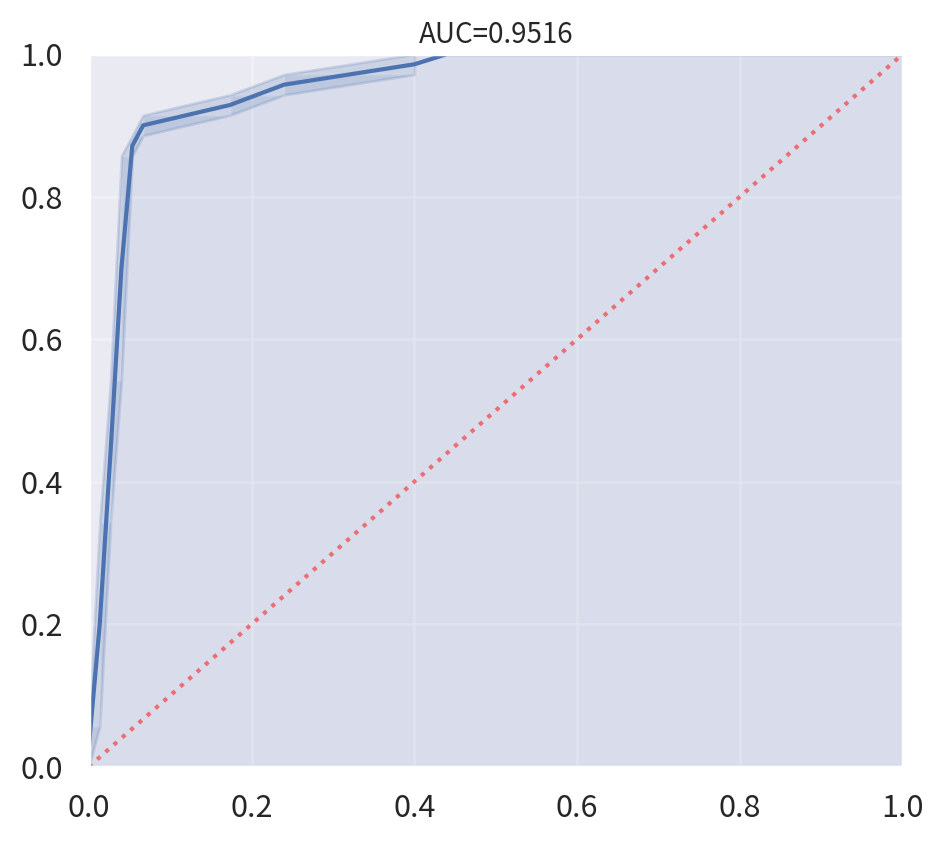

,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
XGBClassifier,0.900,0.900,0.771,0.040,0.960,0.831,0.952


In [9]:
# LAB 09 공통 함수: 이진 분류 성능평가 + ROC 곡선
score_df = hs_cls_bin_scores(clf, X_test, y_test)
score_df

In [10]:
# (02-07과 동일 흐름) 혼동행렬 시각화는 생략. 성능 지표는 위 hs_cls_bin_scores에서 확인.

In [11]:
# ROC 곡선은 위 hs_cls_bin_scores() 내부에서 이미 출력됨. (02-07과 동일)

## (참고) 4.5 과적합 판정

02-07과 동일한 흐름으로 **과적합·일반화 판정은 4.6 학습 곡선(hs_learning_cv)**에서 Train/CV 곡선으로 수행합니다.

In [12]:
# (02-07과 동일) Train vs Test / CV 비교는 4.6 학습곡선(hs_learning_cv)으로 통일. 필요 시 위 참고.

## 4.6 학습 곡선 및 과적합 판정 (LAB 09 방식)

LAB 09 `02-로지스틱 성능평가.ipynb` #07 과적합 판정 방식을 그대로 사용합니다.
learning_curve(roc_auc) → Train/CV 평균·표준편차 → 과소적합/과대적합/일반화 양호/데이터 부족/판단 보류 → 학습 곡선 그래프.
ROC_AUC 기준이라 곡선이 아래→위로 올라갈 수 있음(정상). 익숙한 "위→아래" 형태는 **4.7 Loss 기반 학습 곡선** 셀을 실행하세요.

In [13]:
# LAB 09 #07: estimator, classname, scoring, cv, train_sizes
estimator = clf
if hasattr(estimator, "named_steps"):
    classname = estimator.named_steps["model"].__class__.__name__
else:
    classname = estimator.__class__.__name__

scoring = "roc_auc"
cv = 5
train_sizes = np.linspace(0.1, 1.0, 10)
n_jobs = -1

train_sizes, train_scores, cv_scores = learning_curve(
    estimator=estimator,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=cv,
    scoring=scoring,
    n_jobs=n_jobs,
    shuffle=False,
    random_state=52,
)

# 분류: ROC_AUC는 그대로 사용 (높을수록 좋음)
train_metric = train_scores
cv_metric = cv_scores
train_mean = train_metric.mean(axis=1)
cv_mean = cv_metric.mean(axis=1)
cv_std = cv_metric.std(axis=1)
final_train = train_mean[-1]
final_cv = cv_mean[-1]
final_std = cv_std[-1]
gap_ratio = final_train - final_cv
var_ratio = final_std

if final_train < 0.6 and final_cv < 0.6:
    status = "⚠ 과소적합"
elif gap_ratio > 0.1:
    status = "⚠ 과대적합"
elif gap_ratio <= 0.05 and var_ratio <= 0.05:
    status = "✅ 일반화 양호"
elif var_ratio > 0.1:
    status = "⚠ 데이터 부족"
else:
    status = "⚠ 판단 보류"

metric_name = scoring.upper()
result_df_lc = DataFrame(
    {
        f"Train {metric_name} 평균": [round(final_train, 3)],
        f"CV {metric_name} 평균": [round(final_cv, 3)],
        f"CV {metric_name} 표준편차": [round(final_std, 3)],
        "Train/CV 비율": [round(gap_ratio, 3)],
        "CV 변동성 비율": [round(var_ratio, 3)],
        "판정 결과": [status],
    },
    index=[classname],
)
result_df_lc

,Train ROC_AUC 평균,CV ROC_AUC 평균,CV ROC_AUC 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
XGBClassifier,0.983,0.960,0.027,0.022,0.027,✅ 일반화 양호


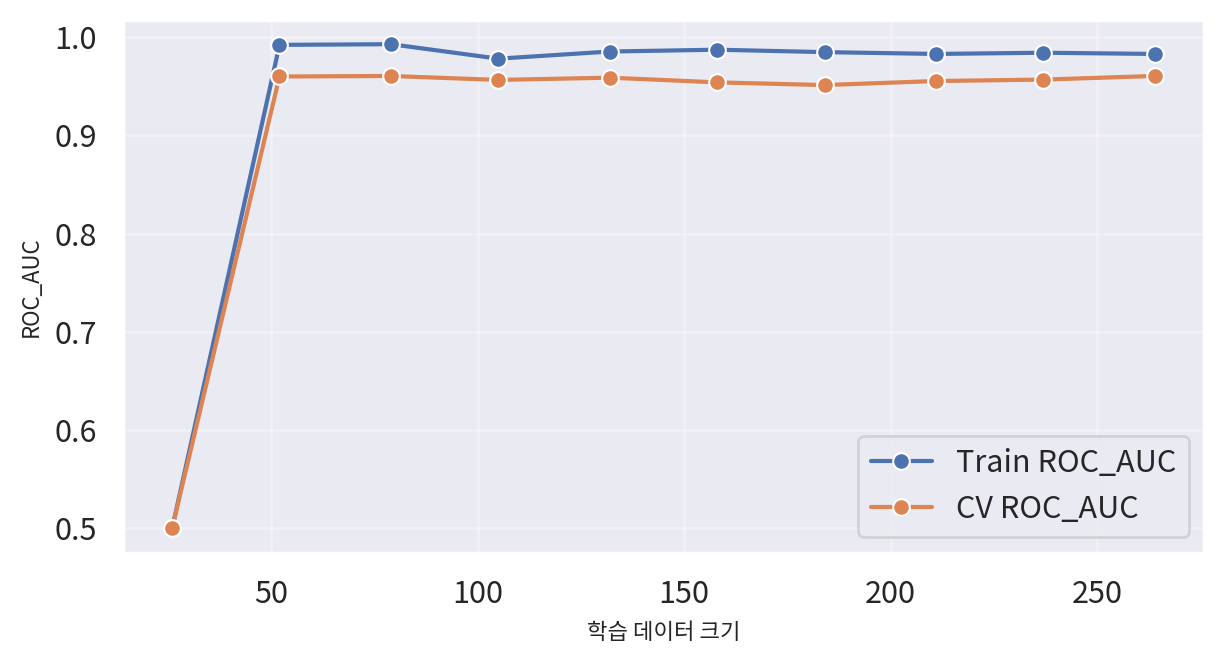

In [14]:
# LAB 09 #07 [2] 학습 곡선 그래프
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)
sb.lineplot(x=train_sizes, y=train_mean, marker="o", markeredgecolor="#ffffff", label=f"Train {metric_name}")
sb.lineplot(x=train_sizes, y=cv_mean, marker="o", markeredgecolor="#ffffff", label=f"CV {metric_name}")
ax.set_xlabel("학습 데이터 크기", fontsize=8)
ax.set_ylabel(metric_name, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [15]:
# 위 두 셀에서 LAB 09 방식으로 과적합 판정 표와 학습 곡선 그래프를 출력했습니다.

## 5. Feature Importance

## 4.7 Loss 기반 학습 곡선 (선택)

같은 학습 곡선을 **오차(Loss)** 기준으로 그리면, 데이터가 늘수록 Train Loss·CV Loss가 **위에서 아래로** 줄어드는 익숙한 형태로 볼 수 있습니다. `scoring='neg_log_loss'`로 계산한 뒤 부호를 반전해 Loss로 표시합니다.

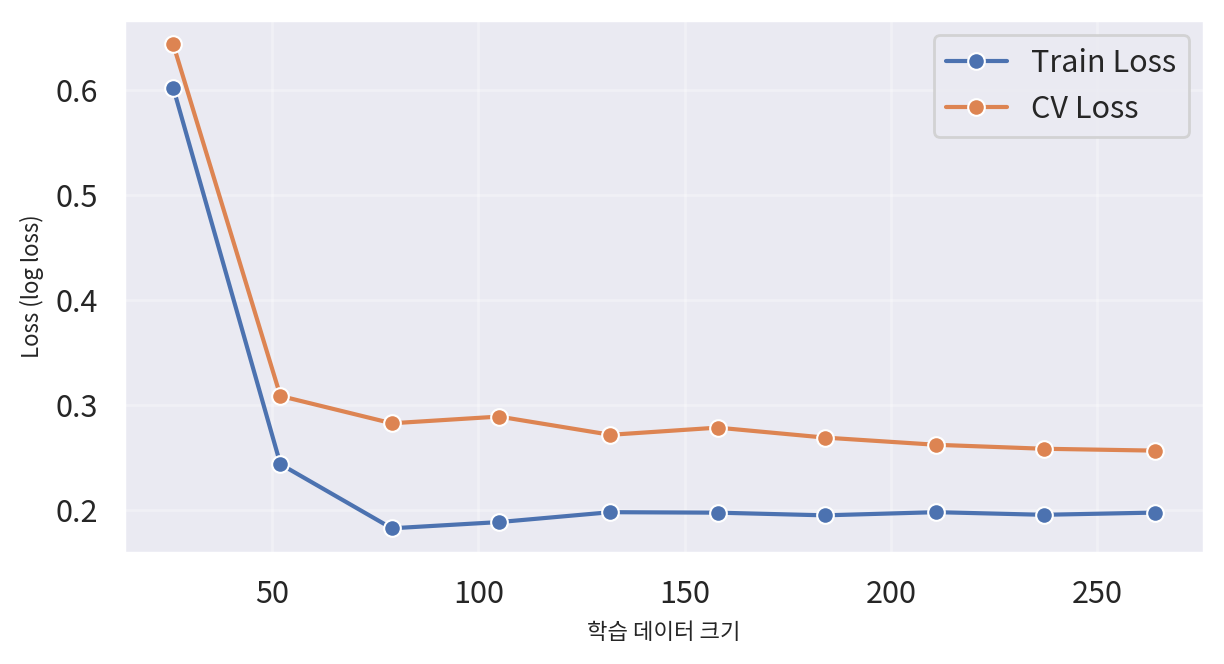

In [16]:
# Loss 기반 학습 곡선 (위→아래 수렴 형태)
train_sizes, train_scores, cv_scores = learning_curve(
    clf, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1,
    random_state=52,
)
train_loss = -train_scores.mean(axis=1)
cv_loss = -cv_scores.mean(axis=1)
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)
sb.lineplot(x=train_sizes, y=train_loss, marker="o", markeredgecolor="#ffffff", label="Train Loss")
sb.lineplot(x=train_sizes, y=cv_loss, marker="o", markeredgecolor="#ffffff", label="CV Loss")
ax.set_xlabel("학습 데이터 크기", fontsize=8)
ax.set_ylabel("Loss (log loss)", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [17]:
imp = DataFrame({
    'feature': FEATURE_COLS,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
imp

,feature,importance
4,log_Detergents_Paper,0.497
2,log_Grocery,0.271
1,log_Milk,0.100
0,log_Fresh,0.056
3,log_Frozen,0.041
5,log_Delicassen,0.036
6,Region,0.000


C:\Users\itwill\AppData\Local\Temp\ipykernel_1444\1166794653.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=imp, x='importance', y='feature', palette='viridis')


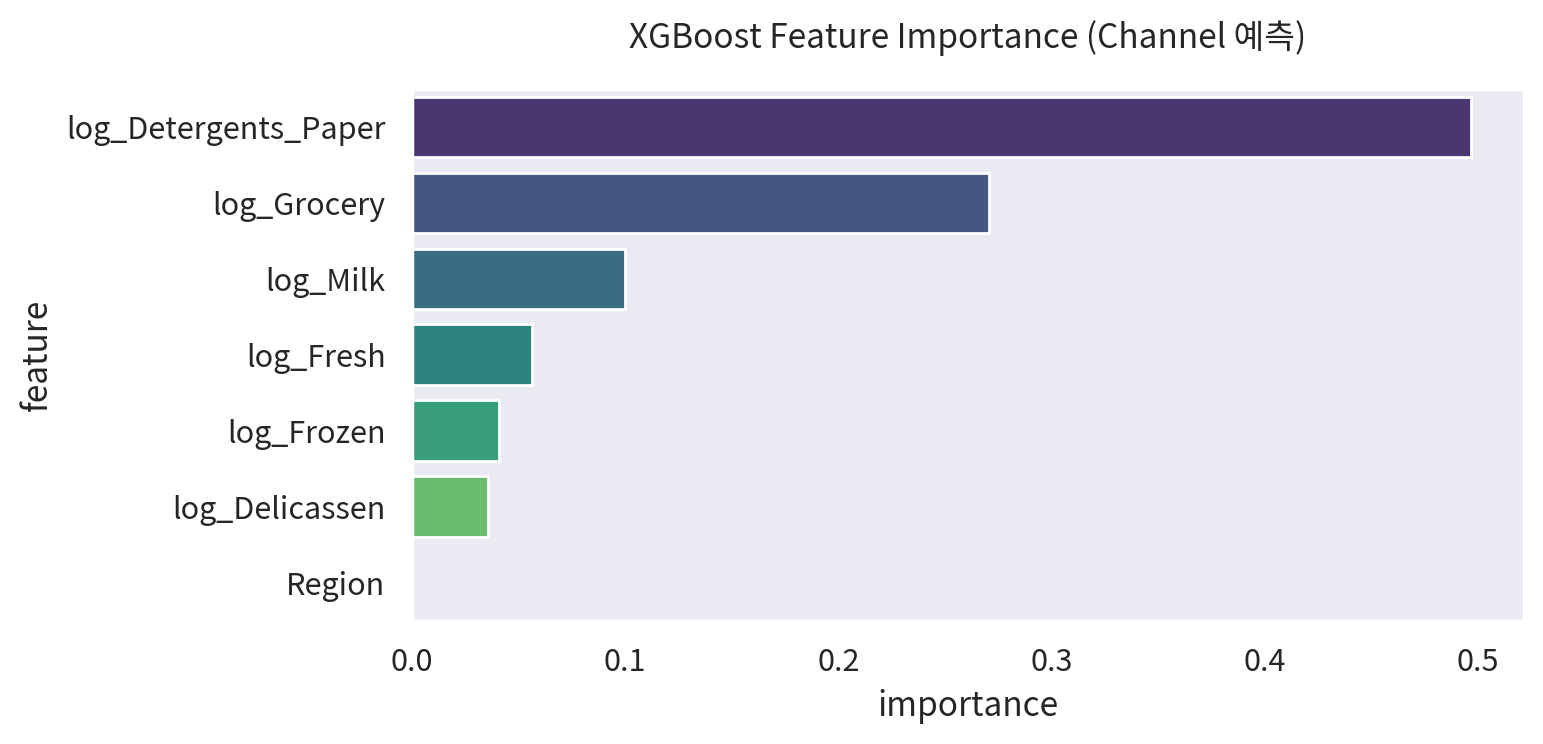

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=my_dpi)
sb.barplot(data=imp, x='importance', y='feature', palette='viridis')
ax.set_title('XGBoost Feature Importance (Channel 예측)')
plt.tight_layout()
plt.show()
plt.close()

## 5.5 SHAP 분석 (모델 해석성)

- **SHAP**: 각 변수가 예측에 얼마나 기여했는지 설명 (TreeExplainer 사용)
- **summary_plot**: 변수별 영향 방향·크기 요약
- **bar_plot**: 변수 중요도 (평균 |SHAP|)

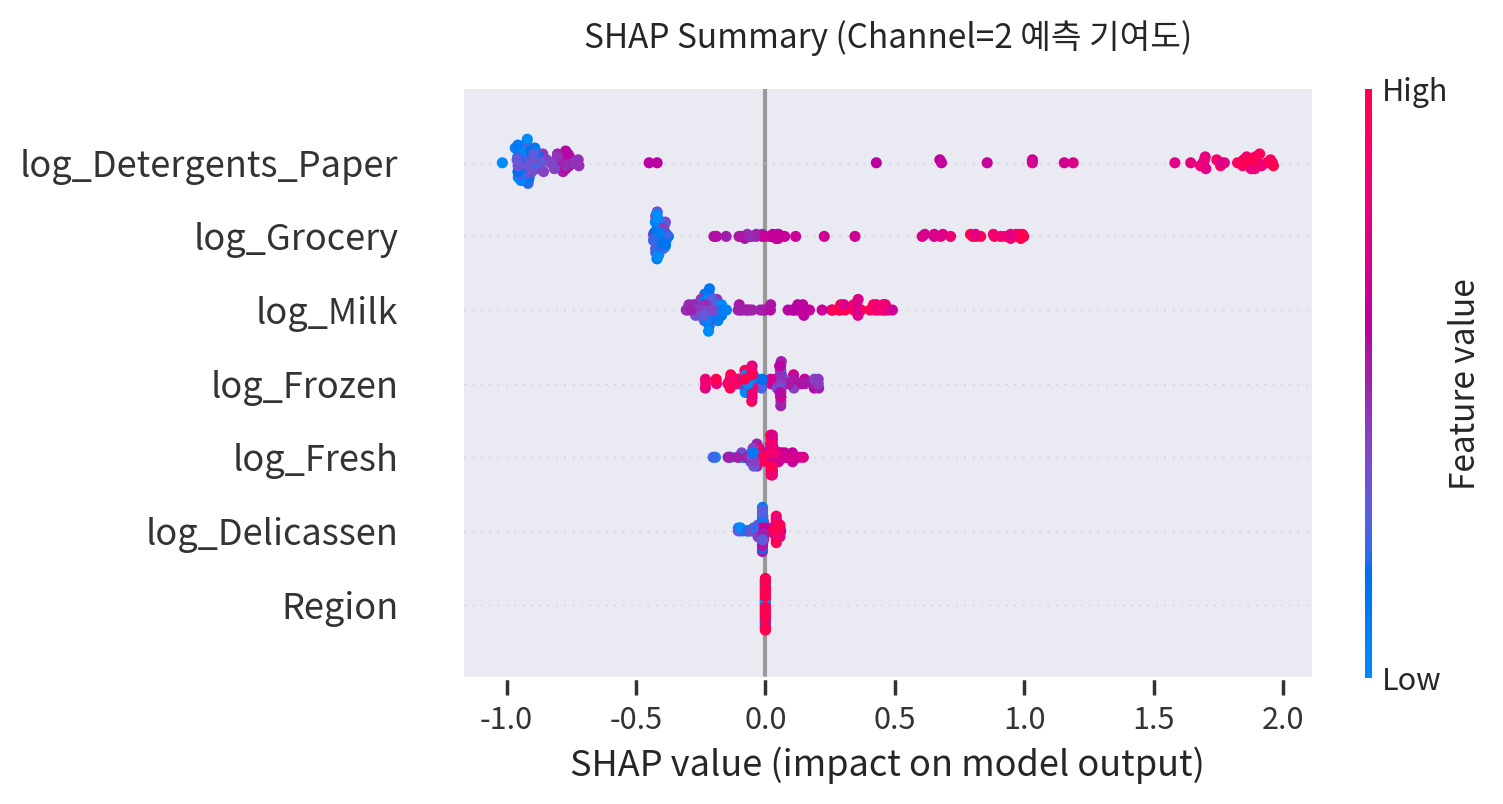

In [19]:
# SHAP: 테스트 세트 기준 설명 (샘플 많으면 시간 걸림)
X_test_df = DataFrame(X_test, columns=FEATURE_COLS)
explainer = shap.TreeExplainer(clf, X_test_df)
shap_values = explainer.shap_values(X_test_df)

# summary plot (Channel=1 양성 클래스 기준, 이진분류면 보통 class 1)
if isinstance(shap_values, list):
    sv = shap_values[1]  # 양성(Channel 2)에 대한 SHAP
else:
    sv = shap_values
shap.summary_plot(sv, X_test_df, show=False)
plt.title('SHAP Summary (Channel=2 예측 기여도)')
plt.tight_layout()
plt.show()
plt.close()

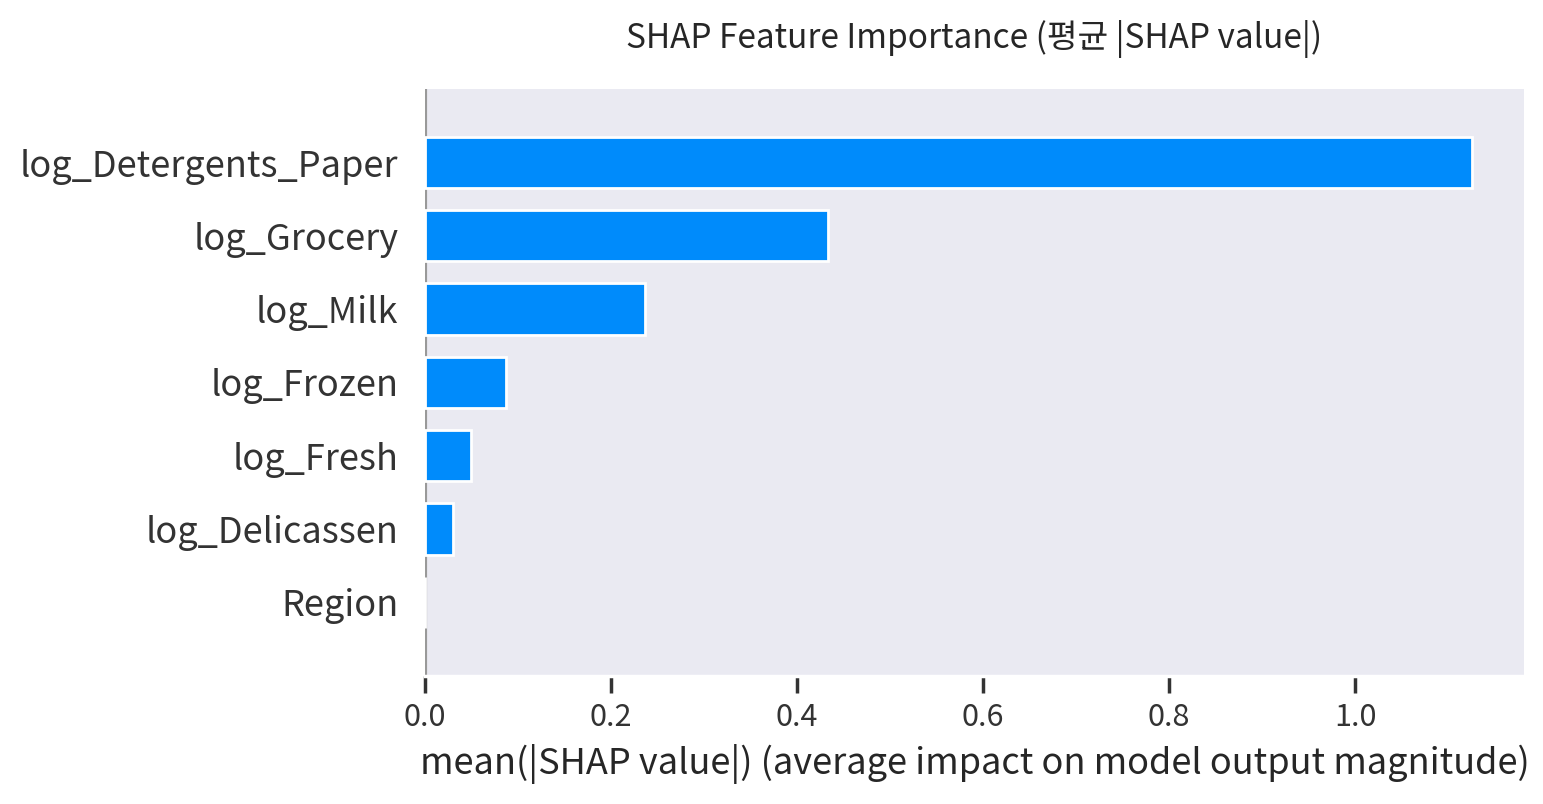

In [20]:
# SHAP Bar: 변수별 평균 |SHAP| (중요도)
shap.summary_plot(sv, X_test_df, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (평균 |SHAP value|)')
plt.tight_layout()
plt.show()
plt.close()

## 6. Scaler / XGB 모델 저장 (TabPy·Tableau 시뮬레이터용)

In [21]:
scaler_path = LAB05_DIR / 'wholesale_scaler.pkl'
model_path = LAB05_DIR / 'wholesale_xgb.pkl'

with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
with open(model_path, 'wb') as f:
    pickle.dump(clf, f)

print('저장 완료:', scaler_path)
print('저장 완료:', model_path)

저장 완료: C:\Machine_Learning\[LAB 05] 비지도 학습 - 구매 패턴 기반 고객 군집 분석과 페르소나 도출\wholesale_scaler.pkl
저장 완료: C:\Machine_Learning\[LAB 05] 비지도 학습 - 구매 패턴 기반 고객 군집 분석과 페르소나 도출\wholesale_xgb.pkl


## 7. TabPy 배포용 함수: 원본 수치 → 예측 클래스 & 확률

Tableau 시뮬레이터에서 **원본 구매액(Raw)** 6개 + **Region**을 넘기면,  
1. np.log1p 적용(구매액만), Region 그대로  
2. 저장된 StandardScaler로 스케일  
3. XGBoost predict_proba  
4. **예측 클래스(0/1)** 와 **양성(Channel=2) 확률** 을 리스트로 반환

In [22]:
def predict_customer_channel(Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen, Region):
    """
    TabPy/Tableau에서 호출할 함수.
    인자: 원본 구매액 6개 + Region (각각 리스트 또는 단일 값)
    반환: (예측 클래스 리스트, 양성 확률 리스트)
    """
    def to_arr(x):
        if hasattr(x, '__len__') and not isinstance(x, (str, bytes)):
            return np.asarray(x, dtype=float)
        return np.asarray([float(x)], dtype=float)

    fresh = to_arr(Fresh)
    milk = to_arr(Milk)
    grocery = to_arr(Grocery)
    frozen = to_arr(Frozen)
    det = to_arr(Detergents_Paper)
    deli = to_arr(Delicassen)
    region = to_arr(Region)

    n = max(len(fresh), len(milk), len(grocery), len(frozen), len(det), len(deli), len(region))
    if n == 0:
        return [], []
    if len(fresh) == 1 and n > 1: fresh = np.full(n, float(fresh.flat[0]))
    if len(milk) == 1 and n > 1: milk = np.full(n, float(milk.flat[0]))
    if len(grocery) == 1 and n > 1: grocery = np.full(n, float(grocery.flat[0]))
    if len(frozen) == 1 and n > 1: frozen = np.full(n, float(frozen.flat[0]))
    if len(det) == 1 and n > 1: det = np.full(n, float(det.flat[0]))
    if len(deli) == 1 and n > 1: deli = np.full(n, float(deli.flat[0]))
    if len(region) == 1 and n > 1: region = np.full(n, float(region.flat[0]))

    raw = np.column_stack([fresh, milk, grocery, frozen, det, deli])
    log = np.log1p(raw)
    full = np.hstack([raw, log, region.reshape(-1, 1)])
    scaled = scaler.transform(full)
    X_in = scaled[:, 6:13]

    proba = clf.predict_proba(X_in)
    pred_class = clf.predict(X_in)
    proba_positive = proba[:, 1].tolist()

    return pred_class.tolist(), proba_positive

In [23]:
# 검증: 테스트 데이터 몇 개로 호출
raw_test = origin[RAW_COLS + ['Region']].iloc[:5].values
p, prob = predict_customer_channel(
    raw_test[:, 0], raw_test[:, 1], raw_test[:, 2],
    raw_test[:, 3], raw_test[:, 4], raw_test[:, 5], raw_test[:, 6]
)
print('예측 클래스:', p)
print('Channel=2 확률:', prob)
print('실제 Channel:', (origin['Channel'].iloc[:5] - 1).tolist())

예측 클래스: [1, 1, 1, 0, 0]
Channel=2 확률: [0.5800841450691223, 0.7966192960739136, 0.732347309589386, 0.05250167101621628, 0.29108014702796936]
실제 Channel: [1, 1, 1, 0, 1]


c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
